<a href="https://colab.research.google.com/github/Devdat24/Smart-Student-Analyzer/blob/main/spp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd

In [17]:
# load data
df = pd.read_csv('/content/student_exam_performance_dataset (1).csv')
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [18]:
df.shape

(10000, 23)

In [19]:
# check basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  object 
 1   gender                      10000 non-null  object 
 2   age                         10000 non-null  int64  
 3   parental_education          10000 non-null  object 
 4   family_income               10000 non-null  object 
 5   internet_access             10000 non-null  object 
 6   study_environment           10000 non-null  object 
 7   study_hours_per_day         10000 non-null  float64
 8   attendance_rate             10000 non-null  float64
 9   sleep_hours                 10000 non-null  float64
 10  social_media_hours          10000 non-null  float64
 11  assignment_completion_rate  10000 non-null  float64
 12  participation_score         10000 non-null  float64
 13  online_courses_completed    1000

In [20]:
# check null values
df.isnull().sum()

,0
student_id,0
gender,0
age,0
parental_education,0
family_income,0
internet_access,0
study_environment,0
study_hours_per_day,0
attendance_rate,0
sleep_hours,0


In [21]:
# check duplicates
df.duplicated().sum()

np.int64(0)

In [22]:
# view summary statistics
df.describe()

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,16.486900,3.019702,84.703770,7.018894,2.51730,79.491450,69.81681,2.029300,49.503410,49.755600,49.650940,49.759010,49.681910,1.984944
std,1.122744,1.179235,9.509211,0.991714,1.44675,13.763237,14.65927,1.437445,13.879156,13.359603,13.436917,13.825207,12.149823,0.544920
min,15.000000,0.500000,50.800000,4.000000,0.00000,40.000000,20.00000,0.000000,0.000000,0.000000,0.000000,4.800000,4.400000,0.000000
25%,15.000000,2.200000,78.275000,6.337500,1.50000,70.200000,59.80000,1.000000,40.000000,40.800000,40.700000,40.300000,41.600000,1.610000
50%,16.000000,3.010000,85.100000,7.030000,2.50000,80.000000,69.90000,2.000000,49.300000,49.600000,49.600000,49.600000,49.550000,1.990000
75%,17.000000,3.830000,91.900000,7.690000,3.50000,90.000000,80.10000,3.000000,58.600000,58.500000,58.600000,59.000000,57.600000,2.350000
max,18.000000,7.240000,100.000000,10.000000,8.00000,100.000000,100.00000,9.000000,100.000000,100.000000,100.000000,100.000000,97.800000,3.990000


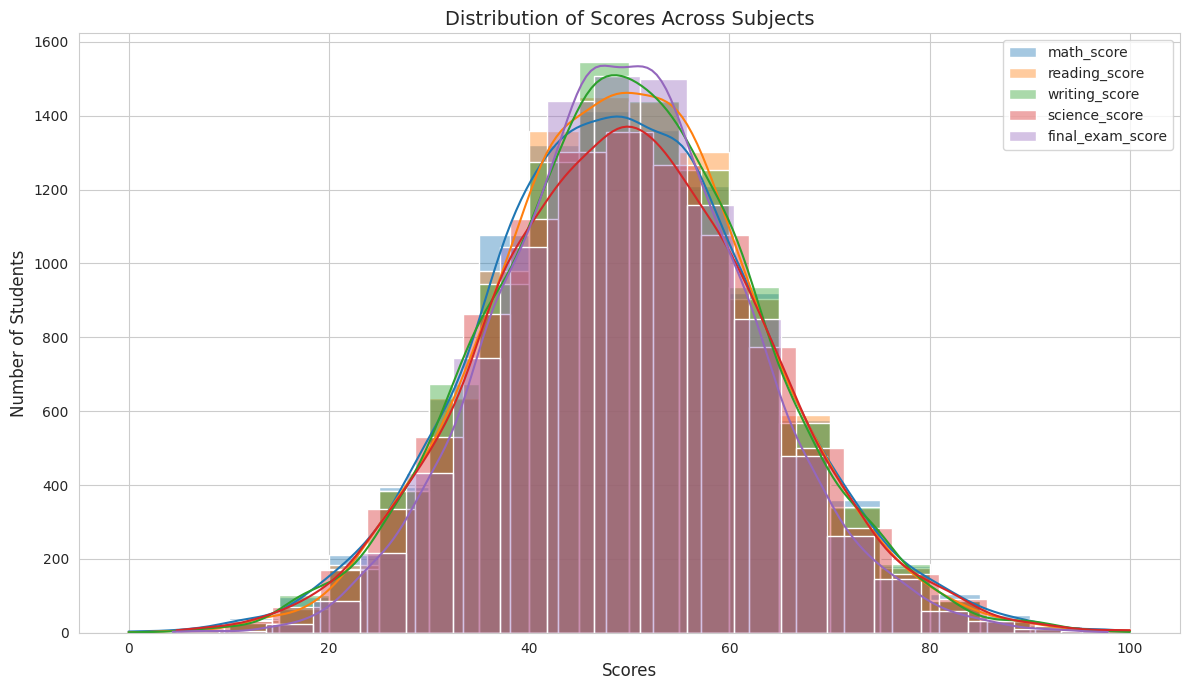

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

score_columns = [
    'math_score',
    'reading_score',
    'writing_score',
    'science_score',
    'final_exam_score'
]

for col in score_columns:
    sns.histplot(df[col], bins=20, kde=True, label=col, alpha=0.4)

plt.title('Distribution of Scores Across Subjects', fontsize=14)
plt.xlabel('Scores', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

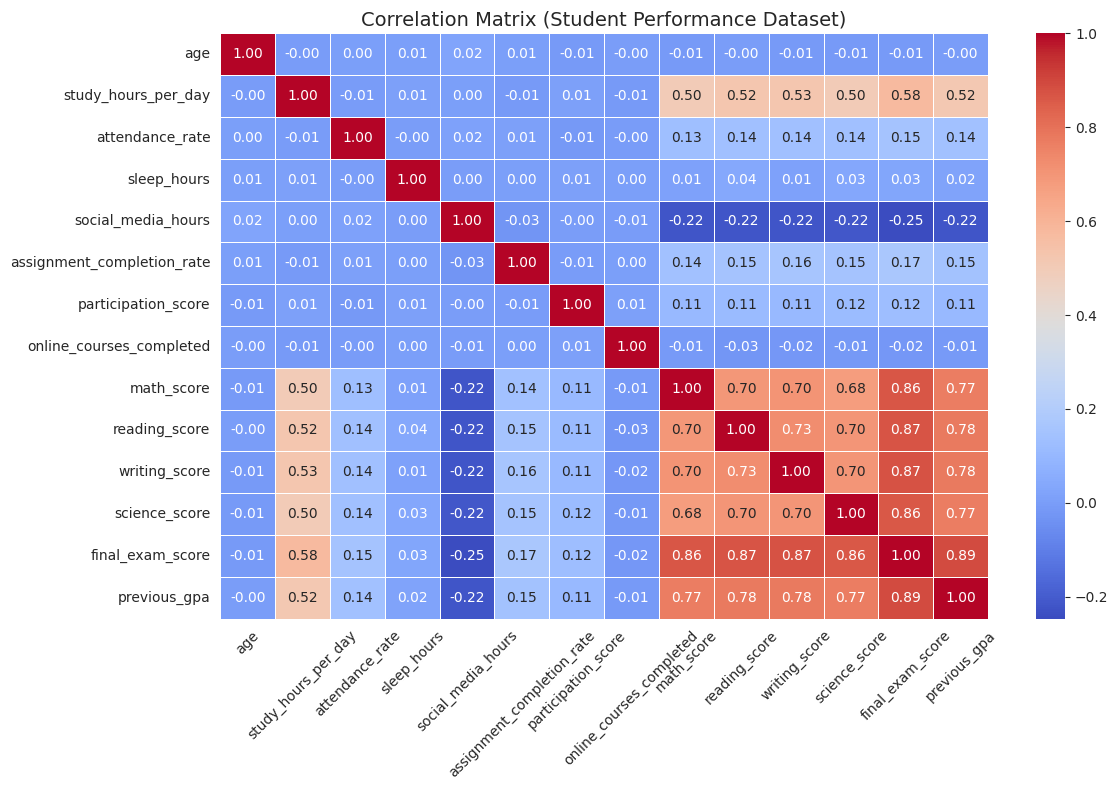

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correct numerical columns from YOUR dataset
numerical_cols = [
    'age',
    'study_hours_per_day',
    'attendance_rate',
    'sleep_hours',
    'social_media_hours',
    'assignment_completion_rate',
    'participation_score',
    'online_courses_completed',
    'math_score',
    'reading_score',
    'writing_score',
    'science_score',
    'final_exam_score',
    'previous_gpa'
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix (Student Performance Dataset)', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

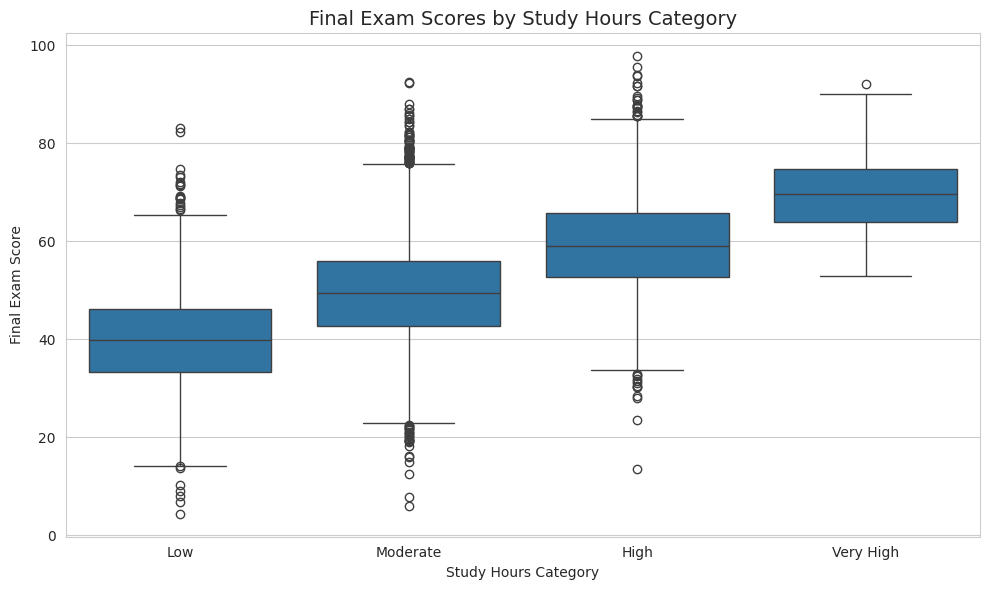

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create categories for study hours
df['study_hours_category'] = pd.cut(
    df['study_hours_per_day'],
    bins=[0, 2, 4, 6, 10],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    x='study_hours_category',
    y='final_exam_score',
    data=df
)

plt.title('Final Exam Scores by Study Hours Category', fontsize=14)
plt.xlabel('Study Hours Category')
plt.ylabel('Final Exam Score')

plt.tight_layout()
plt.show()

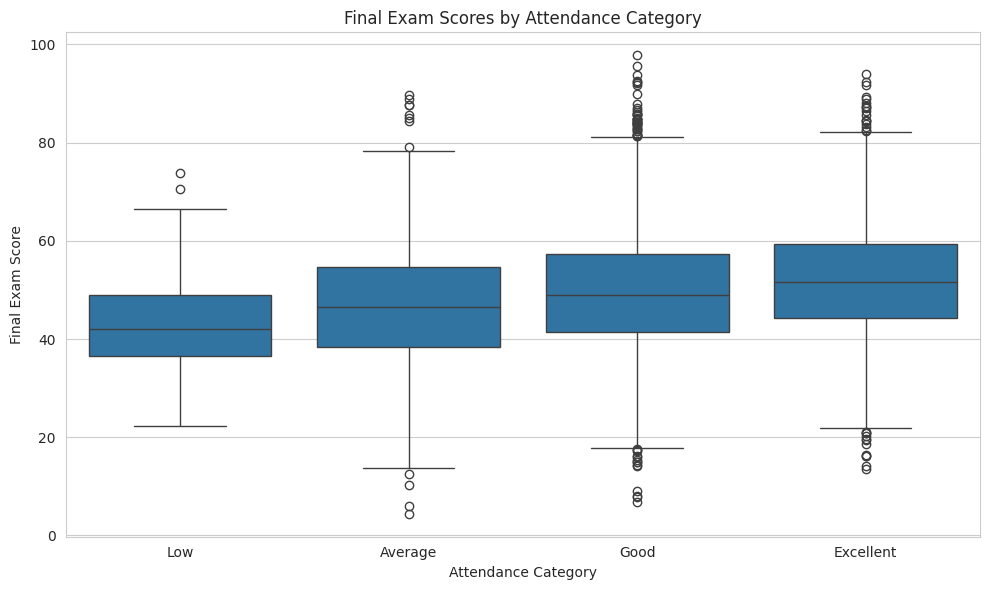

In [26]:
# Create attendance categories
df['attendance_category'] = pd.cut(
    df['attendance_rate'],
    bins=[0, 60, 75, 90, 100],
    labels=['Low', 'Average', 'Good', 'Excellent']
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    x='attendance_category',
    y='final_exam_score',
    data=df
)

plt.title('Final Exam Scores by Attendance Category')
plt.xlabel('Attendance Category')
plt.ylabel('Final Exam Score')

plt.tight_layout()
plt.show()

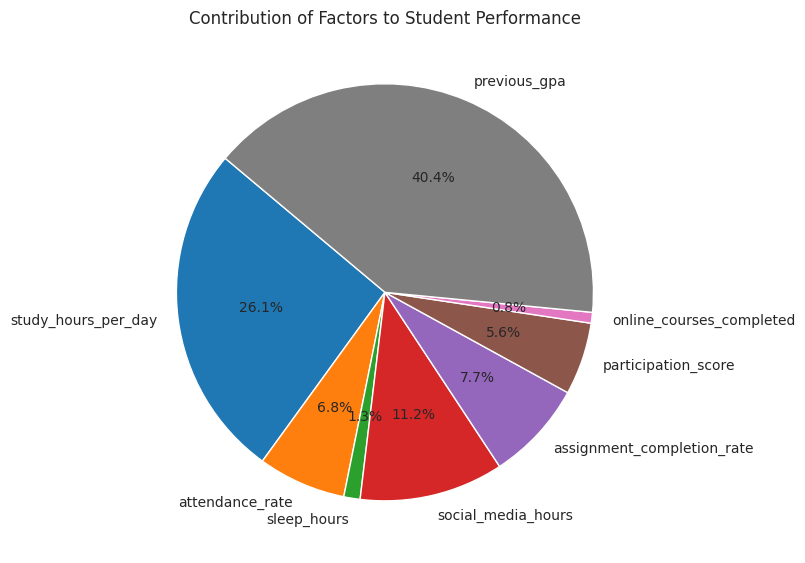

In [27]:
import matplotlib.pyplot as plt

# Select relevant features (excluding target)
features = [
    'study_hours_per_day',
    'attendance_rate',
    'sleep_hours',
    'social_media_hours',
    'assignment_completion_rate',
    'participation_score',
    'online_courses_completed',
    'previous_gpa'
]

# Calculate correlation with final exam score
corr = df[features].corrwith(df['final_exam_score'])

# Take absolute values (importance, ignoring + or -)
corr = corr.abs()

# Convert to percentage
contribution = (corr / corr.sum()) * 100

# Plot pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    contribution,
    labels=contribution.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Contribution of Factors to Student Performance')
plt.tight_layout()
plt.show()

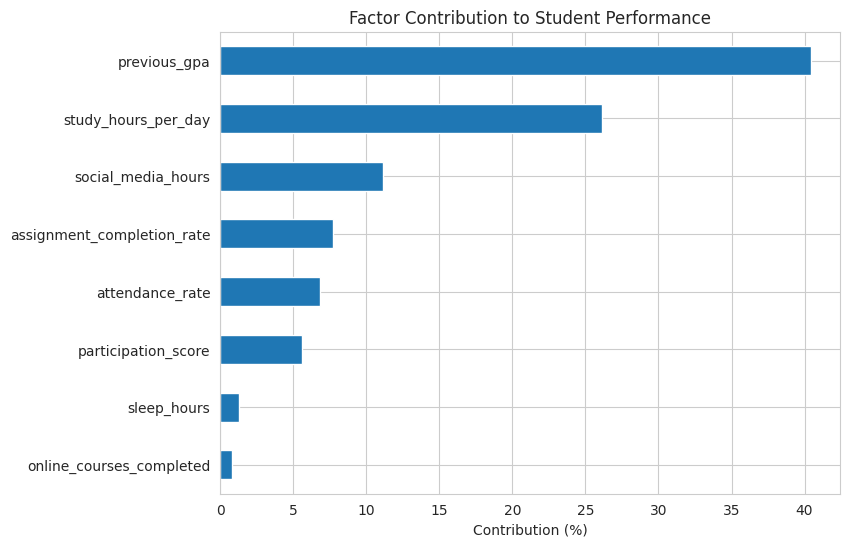

In [28]:
contribution.sort_values().plot(kind='barh', figsize=(8,6))
plt.title('Factor Contribution to Student Performance')
plt.xlabel('Contribution (%)')
plt.show()

In [31]:
import os

os.makedirs("dataset", exist_ok=True)
df.to_csv("dataset/final_student.csv", index=False)

In [32]:
print(df["pass_fail"].value_counts())

pass_fail
Fail    5142
Pass    4858
Name: count, dtype: int64
